# Heart Failure Clinical Records — Classification Assignment

### Objectives
- Dataset ko analyze karna aur samajhna
- Missing values handle karna (agar hon)
- Required encoding perform karna (agar zarurat ho)
- Feature scaling apply karna
- Imbalanced dataset ko balance karna (SMOTE)
- Multiple classification models train karna aur compare karna
- Accuracy, Precision, Recall, F1-Score, Classification Report, Confusion Matrix nikalna
- Best model select karke hyperparameter tuning se performance improve karna



## Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## Load Dataset

In [3]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

print("Shape:", df.shape)
df.head()

Shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [5]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


## Exploratory Data Analysis (EDA)

In [6]:
print("Missing values:\n", df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

Missing values:
 age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Total missing: 0


DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Class Percentage:
DEATH_EVENT
0    67.892977
1    32.107023
Name: proportion, dtype: float64


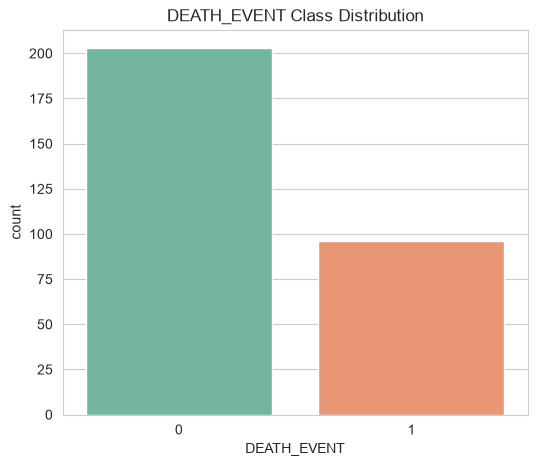

In [10]:
print(df['DEATH_EVENT'].value_counts())
print("\nClass Percentage:")
print(df['DEATH_EVENT'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='DEATH_EVENT', palette='Set2')
plt.title('DEATH_EVENT Class Distribution')
plt.show()

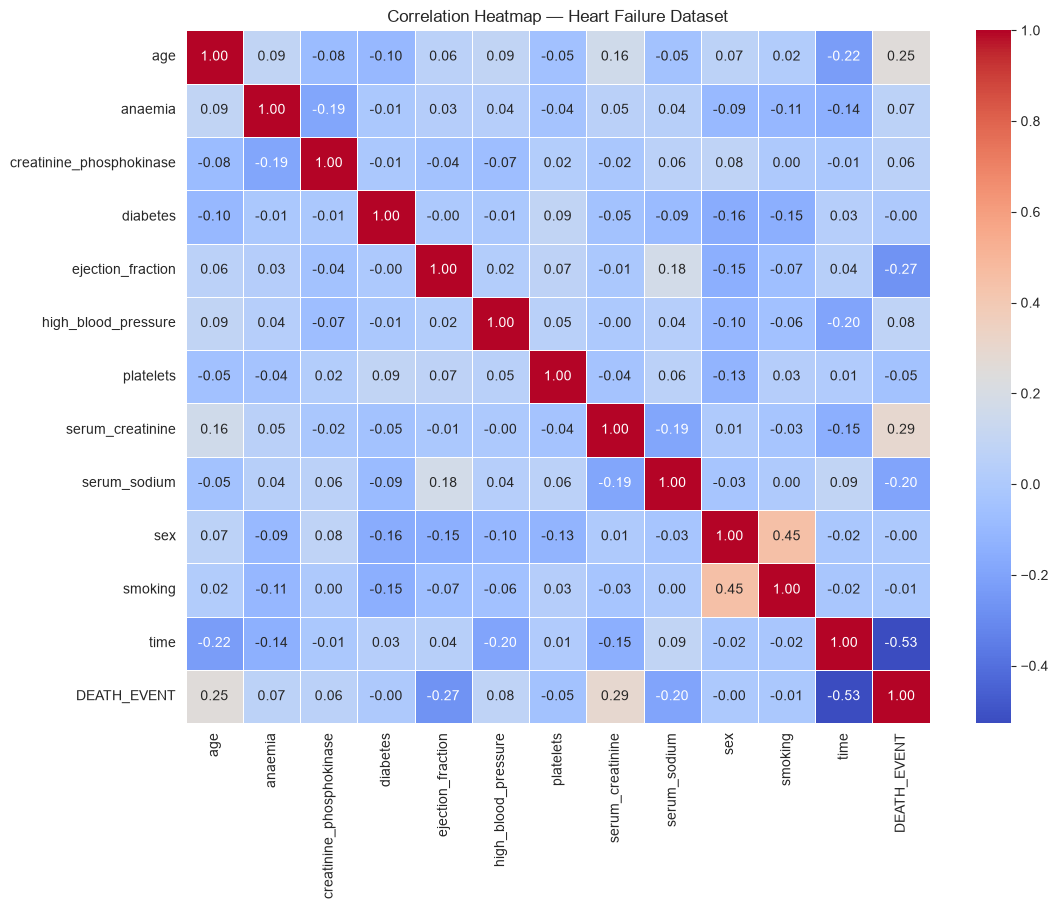

In [11]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Heart Failure Dataset')
plt.show()

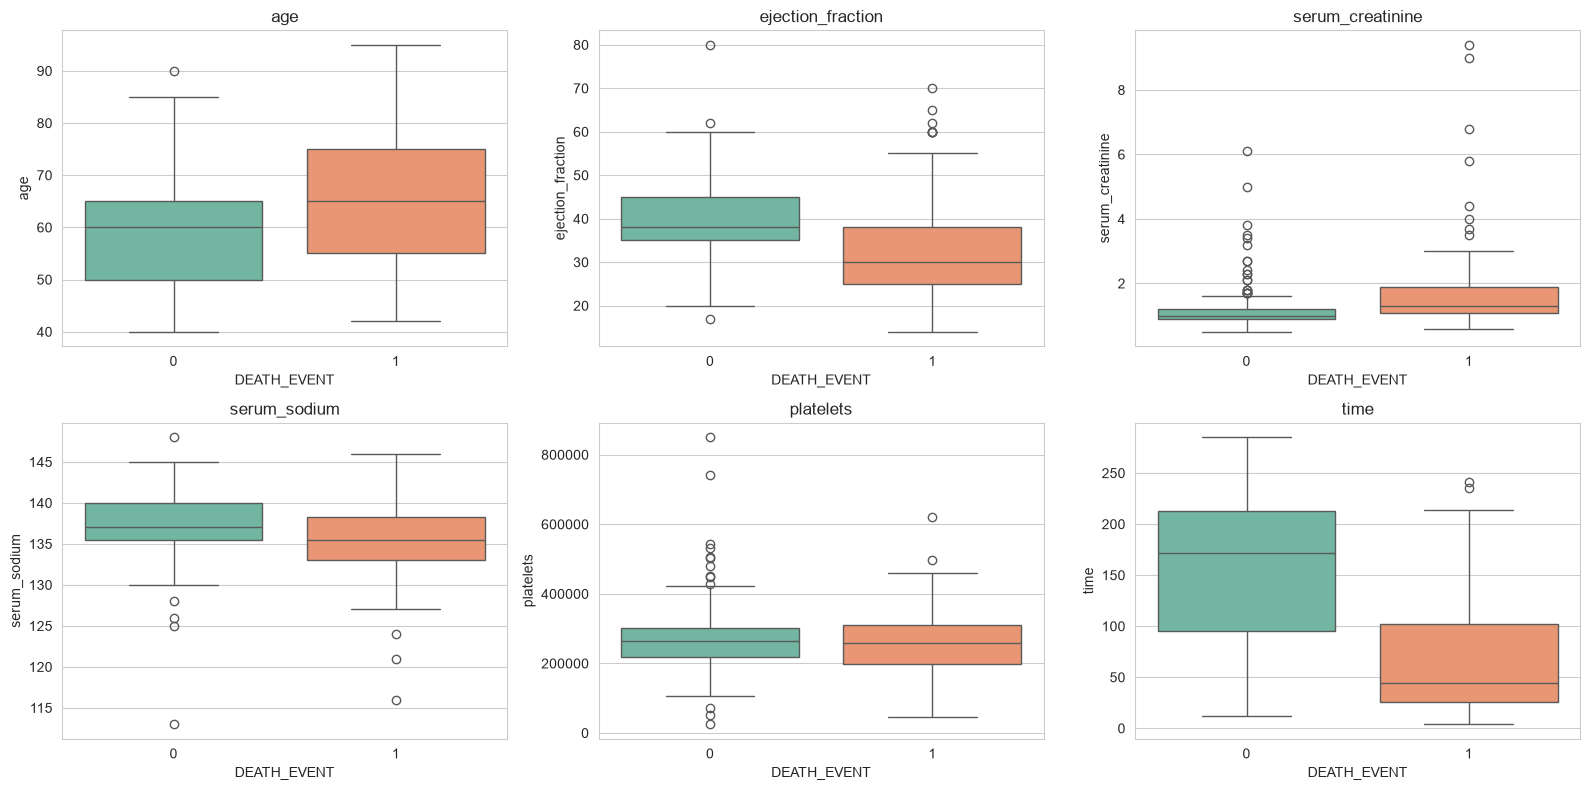

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
key_cols = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'platelets', 'time']

for ax, col in zip(axes.flatten(), key_cols):
    sns.boxplot(data=df, x='DEATH_EVENT', y=col, ax=ax, palette='Set2')
    ax.set_title(col)

plt.tight_layout()
plt.show()

## Data Preprocessing


In [15]:
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (299, 12)
Target shape: (299,)


## Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining class balance:\n", y_train.value_counts())

Training set: (239, 12)
Testing set: (60, 12)

Training class balance:
 DEATH_EVENT
0    162
1     77
Name: count, dtype: int64


## Feature Scaling

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling done")

Feature scaling done


## Handling Class Imbalance (SMOTE)


In [18]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())

Before SMOTE: {0: 162, 1: 77}
After SMOTE: {0: 162, 1: 162}


## Model Building — Multiple Classification Models

In [20]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    trained_models[name] = model

    print(f" {name} trained")

 Logistic Regression trained
 Decision Tree trained
 Random Forest trained
 Gradient Boosting trained
 SVM trained
 KNN trained
 Naive Bayes trained


## Model Evaluation & Comparison

In [21]:
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.816667,0.722222,0.684211,0.702703
1,Gradient Boosting,0.800000,0.666667,0.736842,0.700000
2,Decision Tree,0.783333,0.625000,0.789474,0.697674
3,Logistic Regression,0.800000,0.733333,0.578947,0.647059
4,KNN,0.750000,0.611111,0.578947,0.594595
5,Naive Bayes,0.750000,0.625000,0.526316,0.571429
6,SVM,0.733333,0.588235,0.526316,0.555556


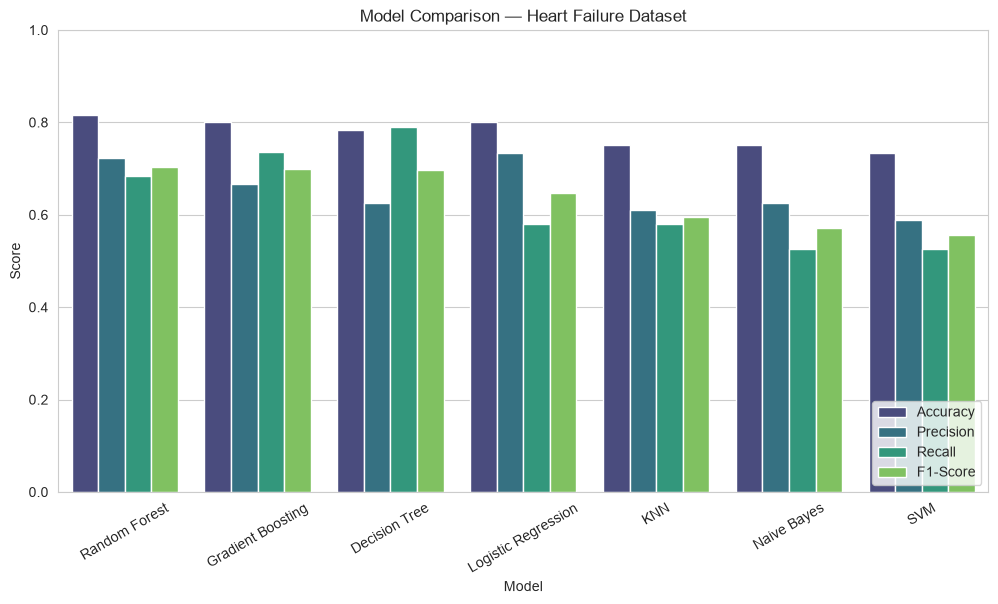

In [23]:
results_melt = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melt, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Model Comparison — Heart Failure Dataset')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

In [24]:
best_model_name = results_df.iloc[0]['Model']
print(f" Best Performing Model (before tuning): {best_model_name}")
print(results_df.iloc[0])

 Best Performing Model (before tuning): Random Forest
Model        Random Forest
Accuracy          0.816667
Precision         0.722222
Recall            0.684211
F1-Score          0.702703
Name: 0, dtype: object


Classification Report — Random Forest

              precision    recall  f1-score   support

           0       0.86      0.88      0.87        41
           1       0.72      0.68      0.70        19

    accuracy                           0.82        60
   macro avg       0.79      0.78      0.79        60
weighted avg       0.81      0.82      0.82        60



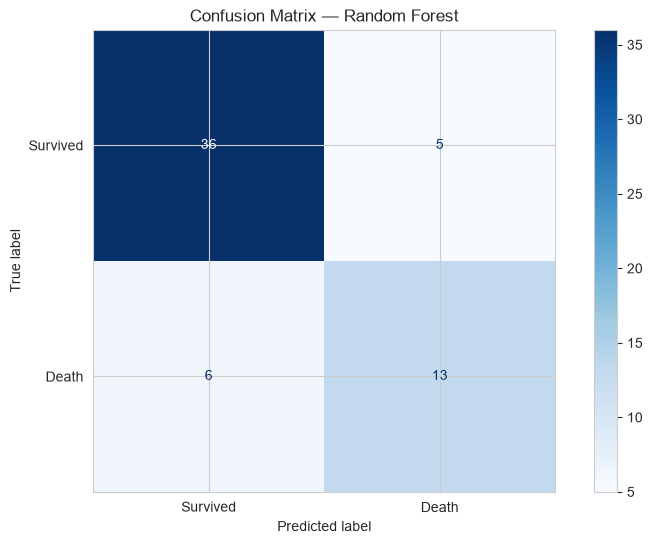

In [25]:
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"Classification Report — {best_model_name}\n")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Death'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

## Hyperparameter Tuning

In [26]:
def get_param_grid(model_name):
    grids = {
        'Random Forest': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        },
        'Gradient Boosting': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5]
        },
        'Decision Tree': {
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        },
        'Logistic Regression': {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l2'],
            'solver': ['lbfgs']
        },
        'SVM': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        },
        'KNN': {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance']
        },
        'Naive Bayes': {
            'var_smoothing': [1e-9, 1e-8, 1e-7]
        }
    }
    return grids[model_name]

if best_model_name == 'Logistic Regression':
    base_model = LogisticRegression(random_state=42, max_iter=1000)
elif best_model_name == 'Random Forest':
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
elif best_model_name == 'Gradient Boosting':
    base_model = GradientBoostingClassifier(random_state=42)
elif best_model_name == 'Decision Tree':
    base_model = DecisionTreeClassifier(random_state=42)
elif best_model_name == 'SVM':
    base_model = SVC(random_state=42, probability=True)
elif best_model_name == 'KNN':
    base_model = KNeighborsClassifier()
else:
    base_model = GaussianNB()

param_grid = get_param_grid(best_model_name)

grid = GridSearchCV(base_model, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train_bal, y_train_bal)

print(f"\n Tuning: {best_model_name}")
print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Tuning: Random Forest
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


 Tuned Random Forest Performance:
Accuracy  : 0.8167
Precision : 0.7000
Recall    : 0.7368
F1-Score  : 0.7179

Before tuning F1 was: 0.7027 -> After tuning: 0.7179

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.85      0.86        41
           1       0.70      0.74      0.72        19

    accuracy                           0.82        60
   macro avg       0.79      0.80      0.79        60
weighted avg       0.82      0.82      0.82        60



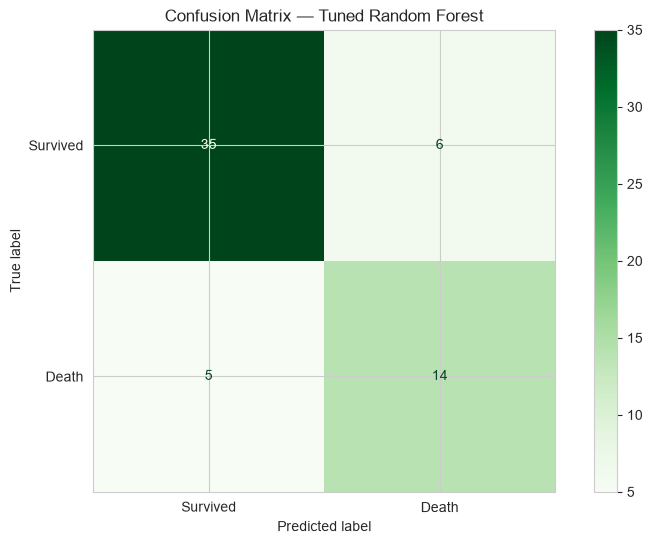

In [27]:
tuned_model = grid.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_scaled)

acc_t = accuracy_score(y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
rec_t = recall_score(y_test, y_pred_tuned)
f1_t = f1_score(y_test, y_pred_tuned)

print(f" Tuned {best_model_name} Performance:")
print(f"Accuracy  : {acc_t:.4f}")
print(f"Precision : {prec_t:.4f}")
print(f"Recall    : {rec_t:.4f}")
print(f"F1-Score  : {f1_t:.4f}")
print(f"\nBefore tuning F1 was: {results_df.iloc[0]['F1-Score']:.4f} -> After tuning: {f1_t:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned))

cm_t = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_t, display_labels=['Survived', 'Death'])
disp.plot(cmap='Greens')
plt.title(f'Confusion Matrix — Tuned {best_model_name}')
plt.show()

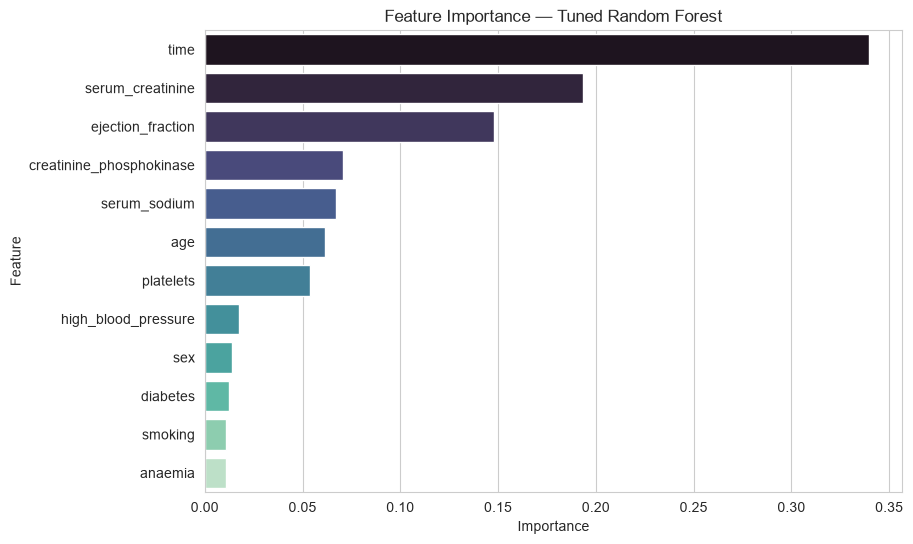

                     Feature  Importance
11                      time    0.339691
7           serum_creatinine    0.193295
4          ejection_fraction    0.148005
2   creatinine_phosphokinase    0.070553
8               serum_sodium    0.067309
0                        age    0.061716
6                  platelets    0.053957
5        high_blood_pressure    0.017504
9                        sex    0.013856
3                   diabetes    0.012264
10                   smoking    0.010996
1                    anaemia    0.010852


In [28]:
if hasattr(tuned_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'Feature': X.columns,
        'Importance': tuned_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=fi, x='Importance', y='Feature', palette='mako')
    plt.title(f'Feature Importance — Tuned {best_model_name}')
    plt.show()

    print(fi)
elif hasattr(tuned_model, 'coef_'):
    fi = pd.DataFrame({
        'Feature': X.columns,
        'Importance': np.abs(tuned_model.coef_[0])
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=fi, x='Importance', y='Feature', palette='mako')
    plt.title(f'Feature Coefficient Magnitude — Tuned {best_model_name}')
    plt.show()

    print(fi)
else:
    print(f"{best_model_name} does not expose feature importance/coefficients directly.")